# Scrap & Rework Agent (m5) - Complete Implementation
## Production Planning AI Agent System

**Model:** XGBoost Gradient Boosting Classifier  
**Purpose:** Real-time scrap risk scoring and root cause analysis  
**Alert Thresholds:** WARN >40% | ESCALATE >60%  

This notebook contains:
1. Synthetic data generation
2. Feature engineering
3. Model training (XGBoost)
4. Model evaluation
5. Model artifacts saving
6. Inference testing

In [2]:
import sys
!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 2.9 MB/s eta 0:00:35
    --------------------------------------- 1.6/101.7 MB 3.4 MB/s eta 0:00:30
    --------------------------------------- 2.4/101.7 MB 3.5 MB/s eta 0:00:29
   - -------------------------------------- 3.1/101.7 MB 3.7 MB/s eta 0:00:27
   - -------------------------------------- 4.2/101.7 MB 3.6 MB/s eta 0:00:27
   -- ------------------------------------- 5.2/101.7 MB 3.8 MB/s eta 0:00:26
   -- ------------------------------------- 5.8/101.7 MB 3.7 MB/s eta 0:00:26
   -- ------------------------------------- 6.8/101.7 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 7.3/101.7 MB 3.8 MB/s eta 0:00:26
   --- -------

## 1. Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import json
from datetime import datetime, timedelta
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, 
    classification_report, 
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Generate Synthetic Training Data

In [4]:
def generate_synthetic_scrap_data(n_samples=1000, random_state=42):
    """
    Generate synthetic scrap & quality inspection data.
    In production, replace this with actual database query.
    """
    np.random.seed(random_state)
    
    # Time range
    start_date = datetime(2025, 1, 1)
    dates = [start_date + timedelta(days=np.random.randint(0, 90)) for _ in range(n_samples)]
    
    # Categorical dimensions
    machines = [f'MC-{i:02d}' for i in range(1, 11)]
    machine_types = ['CNC Lathe', 'CNC Milling', 'Surface Grinder', 'Hydraulic Press',
                     'MIG Welder', 'Robotic Assembly', 'CMM', 'Assembly']
    work_centres = [f'WC-{i:02d}' for i in range(1, 6)]
    shifts = ['Morning', 'Afternoon', 'Night']
    defect_types = ['Operator Error', 'Dimensional', 'Material Fault', 'Surface Finish', 'Machine Setup']
    material_groups = ['Metal Components', 'Steel & Alloys', 'Mechanical Parts',
                       'Raw Materials', 'Electronic Components']
    suppliers = [f'SUP-{i:02d}' for i in range(1, 16)]
    
    data = []
    
    for i in range(n_samples):
        # Core identifiers
        machine_id = np.random.choice(machines)
        machine_type = np.random.choice(machine_types)
        work_centre = np.random.choice(work_centres)
        shift = np.random.choice(shifts)
        defect_type = np.random.choice(defect_types)
        material_group = np.random.choice(material_groups)
        supplier_id = np.random.choice(suppliers)
        inspection_date = dates[i]
        
        # Machine health
        calibration_interval = 90
        maintenance_interval = 30
        calibration_lag = np.random.randint(0, 120)
        maintenance_lag = np.random.randint(0, 60)
        calibration_overdue = 1 if calibration_lag > calibration_interval else 0
        maintenance_overdue = 1 if maintenance_lag > maintenance_interval else 0
        
        # Supplier performance
        supplier_otif_pct = np.random.uniform(70, 99)
        supplier_scrap_pct = np.random.uniform(0, 20)
        supplier_risk_score = np.random.uniform(20, 90)
        
        # Work centre load
        wc_utilization = np.random.uniform(50, 100)
        wc_overload_prob = max(0, (wc_utilization - 80) / 20) if wc_utilization > 80 else 0
        
        # Order context
        order_overload_prob = np.random.uniform(0, 0.8)
        throughput_deviation_pct = np.random.uniform(-20, 20)
        
        # Inspection quantities
        inspected_qty = np.random.randint(50, 500)
        
        # Generate risk-based defect rates
        risk_multiplier = 1.0
        if calibration_overdue:
            risk_multiplier *= 2.0
        if maintenance_overdue:
            risk_multiplier *= 1.5
        if shift == 'Night':
            risk_multiplier *= 1.3
        if supplier_otif_pct < 85:
            risk_multiplier *= 1.4
        if supplier_risk_score > 60:
            risk_multiplier *= 1.5
        if wc_utilization > 85:
            risk_multiplier *= 1.2
        
        base_defect_rate = np.random.uniform(1, 8)
        defect_rate_pct = min(50, base_defect_rate * risk_multiplier)
        
        base_scrap_rate = np.random.uniform(0.5, 5)
        scrap_rate_pct = min(30, base_scrap_rate * risk_multiplier)
        
        base_rework_rate = np.random.uniform(1, 6)
        rework_rate_pct = min(25, base_rework_rate * risk_multiplier)
        
        scrap_qty = int(inspected_qty * scrap_rate_pct / 100)
        rework_qty = int(inspected_qty * rework_rate_pct / 100)
        
        # Scrap cost
        unit_cost = np.random.uniform(5, 150)
        scrap_cost_eur = scrap_qty * unit_cost
        
        # Target: scrap risk probability
        scrap_risk_probability = min(0.95, (defect_rate_pct + scrap_rate_pct * 2 + rework_rate_pct) / 60)
        
        # Rolling rates (simplified)
        rolling_scrap_4w_machine_id = scrap_rate_pct + np.random.uniform(-2, 2)
        rolling_scrap_4w_shift = scrap_rate_pct + np.random.uniform(-1.5, 1.5)
        
        data.append({
            'inspection_lot': f'IL-{i+1000:05d}',
            'production_order_no': 4000 + i,
            'inspection_date': inspection_date,
            'week_no': inspection_date.isocalendar()[1],
            'material_no': f'M-{np.random.randint(1000, 9999)}',
            'machine_id': machine_id,
            'machine_name': f'{machine_type} {machine_id}',
            'machine_type': machine_type,
            'work_centre': work_centre,
            'shift': shift,
            'defect_type': defect_type,
            'defect_rate_pct': round(defect_rate_pct, 2),
            'scrap_rate_pct': round(scrap_rate_pct, 2),
            'rework_rate_pct': round(rework_rate_pct, 2),
            'inspected_qty': inspected_qty,
            'scrap_qty': scrap_qty,
            'rework_qty': rework_qty,
            'scrap_cost_eur': round(scrap_cost_eur, 2),
            'unit_cost_eur': round(unit_cost, 2),
            'calibration_lag_days': calibration_lag,
            'maintenance_lag_days': maintenance_lag,
            'calibration_interval_days': calibration_interval,
            'maintenance_interval_days': maintenance_interval,
            'calibration_overdue': calibration_overdue,
            'maintenance_overdue': maintenance_overdue,
            'supplier_id': supplier_id,
            'supplier_name': f'Supplier {supplier_id}',
            'supplier_otif_pct': round(supplier_otif_pct, 2),
            'supplier_scrap_pct': round(supplier_scrap_pct, 2),
            'supplier_risk_score': round(supplier_risk_score, 2),
            'material_group': material_group,
            'wc_utilization': round(wc_utilization, 2),
            'wc_overload_prob': round(wc_overload_prob, 4),
            'order_overload_prob': round(order_overload_prob, 4),
            'throughput_deviation_pct': round(throughput_deviation_pct, 2),
            'rolling_scrap_4w_machine_id': round(rolling_scrap_4w_machine_id, 2),
            'rolling_scrap_4w_shift': round(rolling_scrap_4w_shift, 2),
            'target_scrap_risk': round(scrap_risk_probability, 4)
        })
    
    return pd.DataFrame(data)

# Generate data
df = generate_synthetic_scrap_data(n_samples=1000)
print(f'✅ Generated {len(df)} inspection records')
print(f'Date range: {df["inspection_date"].min()} to {df["inspection_date"].max()}')
df.head()

✅ Generated 1000 inspection records
Date range: 2025-01-01 00:00:00 to 2025-03-31 00:00:00


,inspection_lot,production_order_no,inspection_date,week_no,material_no,machine_id,machine_name,machine_type,work_centre,shift,defect_type,defect_rate_pct,scrap_rate_pct,rework_rate_pct,inspected_qty,scrap_qty,rework_qty,scrap_cost_eur,unit_cost_eur,calibration_lag_days,maintenance_lag_days,calibration_interval_days,maintenance_interval_days,calibration_overdue,maintenance_overdue,supplier_id,supplier_name,supplier_otif_pct,supplier_scrap_pct,supplier_risk_score,material_group,wc_utilization,wc_overload_prob,order_overload_prob,throughput_deviation_pct,rolling_scrap_4w_machine_id,rolling_scrap_4w_shift,target_scrap_risk
0,IL-01000,4000,2025-02-21,8,M-3192,MC-09,MIG Welder MC-09,MIG Welder,WC-04,Afternoon,Material Fault,7.20,5.46,4.94,344,18,17,1498.83,83.27,4,18,90,30,0,0,SUP-05,Supplier SUP-05,89.29,10.46,45.12,Electronic Components,93.86,0.6930,0.3140,12.66,5.21,5.69,0.3843
1,IL-01001,4001,2025-01-15,3,M-3243,MC-01,CMM MC-01,CMM,WC-02,Afternoon,Machine Setup,5.01,4.99,4.76,280,13,13,1397.66,107.51,50,5,90,30,0,0,SUP-07,Supplier SUP-07,97.26,12.55,43.44,Mechanical Parts,56.96,0.0000,0.6352,4.80,6.10,3.92,0.3292
2,IL-01002,4002,2025-03-13,11,M-3116,MC-06,CNC Milling MC-06,CNC Milling,WC-02,Morning,Material Fault,7.81,11.25,13.80,206,23,28,2253.23,97.97,117,37,90,30,1,1,SUP-01,Supplier SUP-01,85.56,7.58,51.99,Steel & Alloys,80.20,0.0099,0.4018,1.59,12.03,11.38,0.7353
3,IL-01003,4003,2025-03-02,9,M-5146,MC-04,Surface Grinder MC-04,Surface Grinder,WC-02,Afternoon,Dimensional,10.97,1.01,7.15,373,3,26,350.49,116.83,89,12,90,30,0,0,SUP-12,Supplier SUP-12,74.03,2.02,37.92,Mechanical Parts,86.30,0.3152,0.4744,-15.91,0.51,-0.28,0.3358
4,IL-01004,4004,2025-01-21,4,M-1536,MC-08,CNC Lathe MC-08,CNC Lathe,WC-03,Night,Operator Error,3.78,5.48,13.69,480,26,65,147.46,5.67,89,45,90,30,0,1,SUP-05,Supplier SUP-05,75.40,16.75,43.25,Electronic Components,65.57,0.0000,0.1819,4.32,4.82,5.18,0.4739


## 3. Create Target Variable & EDA

In [5]:
# Create binary target
df['target'] = (df['target_scrap_risk'] >= 0.40).astype(int)

print('Target distribution:')
print(df['target'].value_counts(normalize=True))
print(f'\nScrap risk probability stats:')
print(df['target_scrap_risk'].describe())

Target distribution:
target
1    0.636
0    0.364
Name: proportion, dtype: float64

Scrap risk probability stats:
count    1000.000000
mean        0.531824
std         0.241804
min         0.104800
25%         0.330600
50%         0.481850
75%         0.716700
max         0.950000
Name: target_scrap_risk, dtype: float64


## 4. Feature Engineering

In [6]:
# Encoding maps
SHIFT_MAP = {'Morning': 0, 'Afternoon': 1, 'Night': 2}
DEFECT_MAP = {
    'Operator Error': 0, 'Dimensional': 1, 'Material Fault': 2,
    'Surface Finish': 3, 'Machine Setup': 4
}

# Apply encodings
df['shift_encoded'] = df['shift'].map(SHIFT_MAP).fillna(0)
df['defect_type_encoded'] = df['defect_type'].map(DEFECT_MAP).fillna(0)
df['machine_type_encoded'] = df['machine_type'].astype('category').cat.codes
df['material_group_encoded'] = df['material_group'].astype('category').cat.codes

# Engineered features
df['rework_share'] = df['rework_qty'] / (df['scrap_qty'] + df['rework_qty'] + 1e-6)
df['scrap_cost_per_unit'] = df['scrap_cost_eur'] / (df['inspected_qty'] + 1e-6)

print('✅ Feature engineering complete')

✅ Feature engineering complete


## 5. Train XGBoost Model

In [8]:
# Feature set
FEATURES = [
    'defect_rate_pct', 'scrap_rate_pct', 'rework_rate_pct',
    'defect_type_encoded', 'shift_encoded',
    'calibration_lag_days', 'maintenance_lag_days',
    'calibration_overdue', 'maintenance_overdue', 'machine_type_encoded',
    'supplier_otif_pct', 'supplier_scrap_pct', 'supplier_risk_score',
    'wc_utilization', 'wc_overload_prob', 'order_overload_prob',
    'throughput_deviation_pct', 'rolling_scrap_4w_machine_id',
    'rolling_scrap_4w_shift', 'material_group_encoded',
    'rework_share', 'scrap_cost_per_unit'
]

# Prepare data
X = df[FEATURES].fillna(0)
y = df['target']

# Time-based split
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train)}, Test: {len(X_test)}')

# Train model
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2,
    early_stopping_rounds=20,   # ← moved here
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('✅ Model trained')

Train: 800, Test: 200
✅ Model trained


## 6. Model Evaluation

AUC-ROC: 0.9951
Accuracy: 0.9700

              precision    recall  f1-score   support

          OK       0.97      0.94      0.96        68
     At Risk       0.97      0.98      0.98       132

    accuracy                           0.97       200
   macro avg       0.97      0.96      0.97       200
weighted avg       0.97      0.97      0.97       200



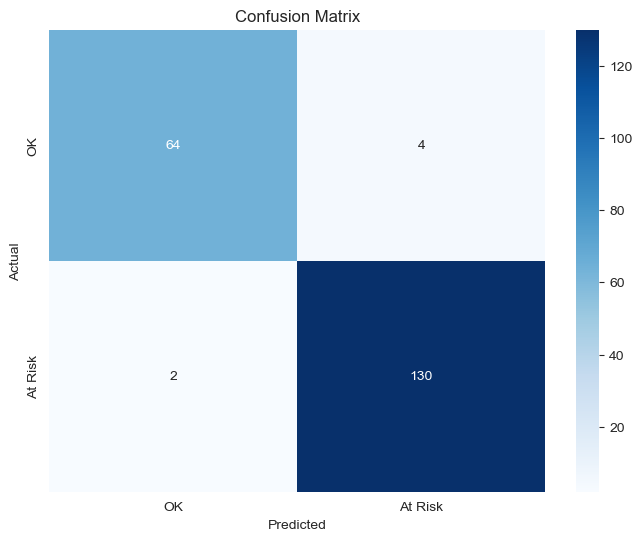

In [9]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
auc_roc = roc_auc_score(y_test, y_prob)
accuracy = accuracy_score(y_test, y_pred)

print(f'AUC-ROC: {auc_roc:.4f}')
print(f'Accuracy: {accuracy:.4f}\n')
print(classification_report(y_test, y_pred, target_names=['OK', 'At Risk']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['OK', 'At Risk'], yticklabels=['OK', 'At Risk'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 7. Feature Importance

Top 10 Most Important Features:
                    feature  importance
             scrap_rate_pct    0.167519
        maintenance_overdue    0.166015
     rolling_scrap_4w_shift    0.109025
            defect_rate_pct    0.108864
        calibration_overdue    0.085608
            rework_rate_pct    0.066533
rolling_scrap_4w_machine_id    0.050053
               rework_share    0.040464
       maintenance_lag_days    0.024506
        scrap_cost_per_unit    0.023985


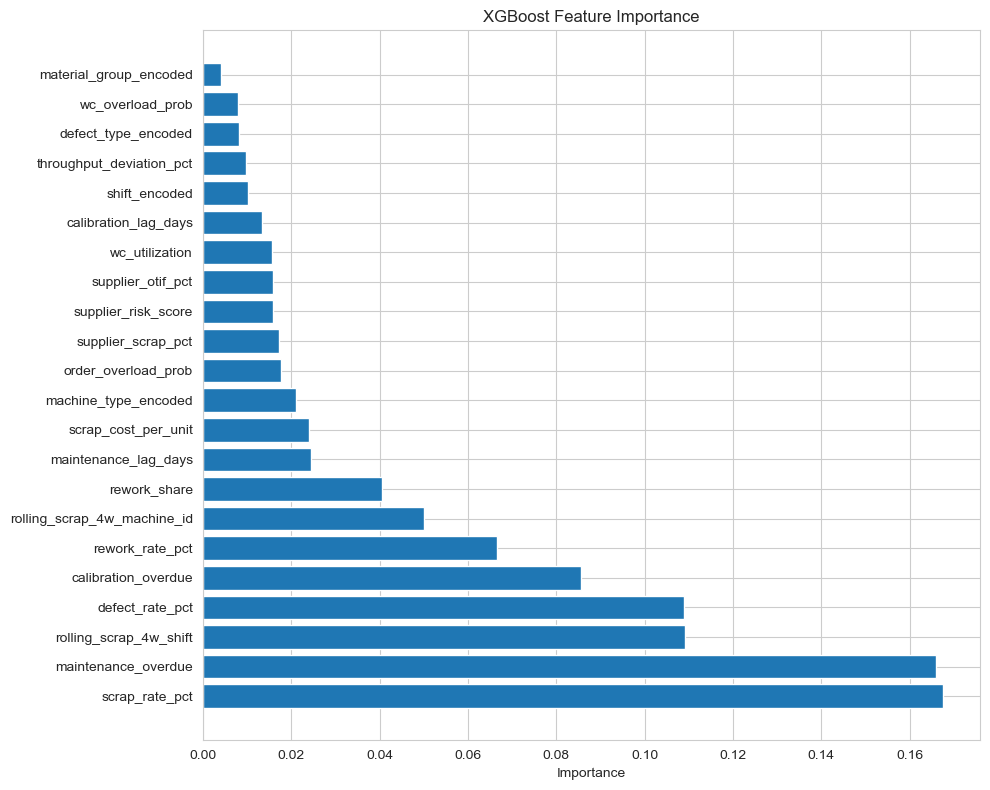

In [10]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 10 Most Important Features:')
print(feature_importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

## 8. Save Model Artifacts

In [11]:
# Create models directory
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

# Save model
joblib.dump(model, models_dir / 'scrap_risk_m5.pkl')
joblib.dump(FEATURES, models_dir / 'scrap_risk_m5_features.pkl')

# Save encodings
encodings = {
    'shift_map': SHIFT_MAP,
    'defect_map': DEFECT_MAP,
    'machine_types': df['machine_type'].astype('category').cat.categories.tolist(),
    'material_groups': df['material_group'].astype('category').cat.categories.tolist()
}
joblib.dump(encodings, models_dir / 'scrap_risk_m5_encodings.pkl')

# Save metrics
metrics = {
    'auc_roc': float(auc_roc),
    'accuracy': float(accuracy),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'feature_count': len(FEATURES),
    'model_version': '1.0.0',
    'training_date': datetime.now().isoformat()
}

with open(models_dir / 'scrap_risk_m5_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'✅ All artifacts saved to {models_dir}/')
print(f'\nModel Performance:')
print(f'  AUC-ROC: {auc_roc:.4f}')
print(f'  Accuracy: {accuracy:.4f}')
print(f'\nNext: Deploy API with scrap_risk_api.py')

✅ All artifacts saved to models/

Model Performance:
  AUC-ROC: 0.9951
  Accuracy: 0.9700

Next: Deploy API with scrap_risk_api.py


## 9. Test Inference

In [12]:
# Test on a sample
sample_idx = 5
sample = X_test.iloc[sample_idx:sample_idx+1]
sample_raw = df.iloc[split_idx + sample_idx]

prob = model.predict_proba(sample)[0, 1]
alert_level = 'ESCALATE' if prob >= 0.60 else 'WARN' if prob >= 0.40 else 'OK'

print('SAMPLE INFERENCE TEST')
print('=' * 60)
print(f'Inspection Lot: {sample_raw["inspection_lot"]}')
print(f'Machine: {sample_raw["machine_id"]} | Shift: {sample_raw["shift"]}')
print(f'Scrap Rate: {sample_raw["scrap_rate_pct"]:.2f}%')
print(f'Calibration Overdue: {bool(sample_raw["calibration_overdue"])}')
print(f'\n🎯 PREDICTION:')
print(f'  Risk Probability: {prob:.4f} ({prob*100:.1f}%)')
print(f'  Alert Level: {alert_level}')
print(f'  True Label: {"At Risk" if y_test.iloc[sample_idx] == 1 else "OK"}')
print('=' * 60)

SAMPLE INFERENCE TEST
Inspection Lot: IL-01805
Machine: MC-07 | Shift: Morning
Scrap Rate: 4.26%
Calibration Overdue: False

🎯 PREDICTION:
  Risk Probability: 0.0032 (0.3%)
  Alert Level: OK
  True Label: OK
